In [1]:
!pip install pandas matplotlib


In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("student_performance.csv")

In [6]:
print("DATASET PREVIEW")
df.head()

DATASET PREVIEW


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [7]:
conn = sqlite3.connect("students.db")

In [8]:
df.to_sql("students", conn, if_exists="replace", index=False)

30

In [9]:
print("\nDatabase created successfully!")


Database created successfully!


In [10]:
query1 = """
SELECT department,
ROUND(AVG(math_score),2) AS avg_math_score
FROM students
GROUP BY department
ORDER BY avg_math_score DESC
"""

In [11]:
chart1 = pd.read_sql_query(query1, conn)

In [12]:
print("\n PANEL 1 DATA ")
print(chart1)


 PANEL 1 DATA 
         department  avg_math_score
0  Computer Science           85.62
1        Mechanical           71.00
2       Electronics           71.00
3             Civil           63.40


In [13]:
query2 = """
SELECT department,
COUNT(*) AS student_count
FROM students
GROUP BY department
"""

In [14]:
chart2 = pd.read_sql_query(query2, conn)

In [15]:
print("\n  PANEL 2 DATA ")
print(chart2)


  PANEL 2 DATA 
         department  student_count
0             Civil              5
1  Computer Science             13
2       Electronics              6
3        Mechanical              6


In [20]:
query3 = """
SELECT name,
       (math_score + science_score + english_score + programming_score) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
"""

In [22]:
chart3 = pd.read_sql_query(query3, conn)
print("\n  PANEL 3 DATA ")
print(chart3)



  PANEL 3 DATA 
             name  total_score
0      Ananya Das          371
1     Tanvi Mehta          367
2  Akanksha Yadav          365
3      Arjun Nair          356
4     Divya Singh          356
5  Swati Kulkarni          354
6       Amit Bose          336
7      Suresh Rao          334


In [23]:
query4 = """
SELECT gender,
ROUND(AVG(attendance_percentage),2) AS avg_attendance
FROM students
GROUP BY gender
"""

In [24]:
chart4 = pd.read_sql_query(query4, conn)
print("\n  PANEL 4 DATA ")
print(chart4)



  PANEL 4 DATA 
   gender  avg_attendance
0  Female           88.53
1    Male           80.47


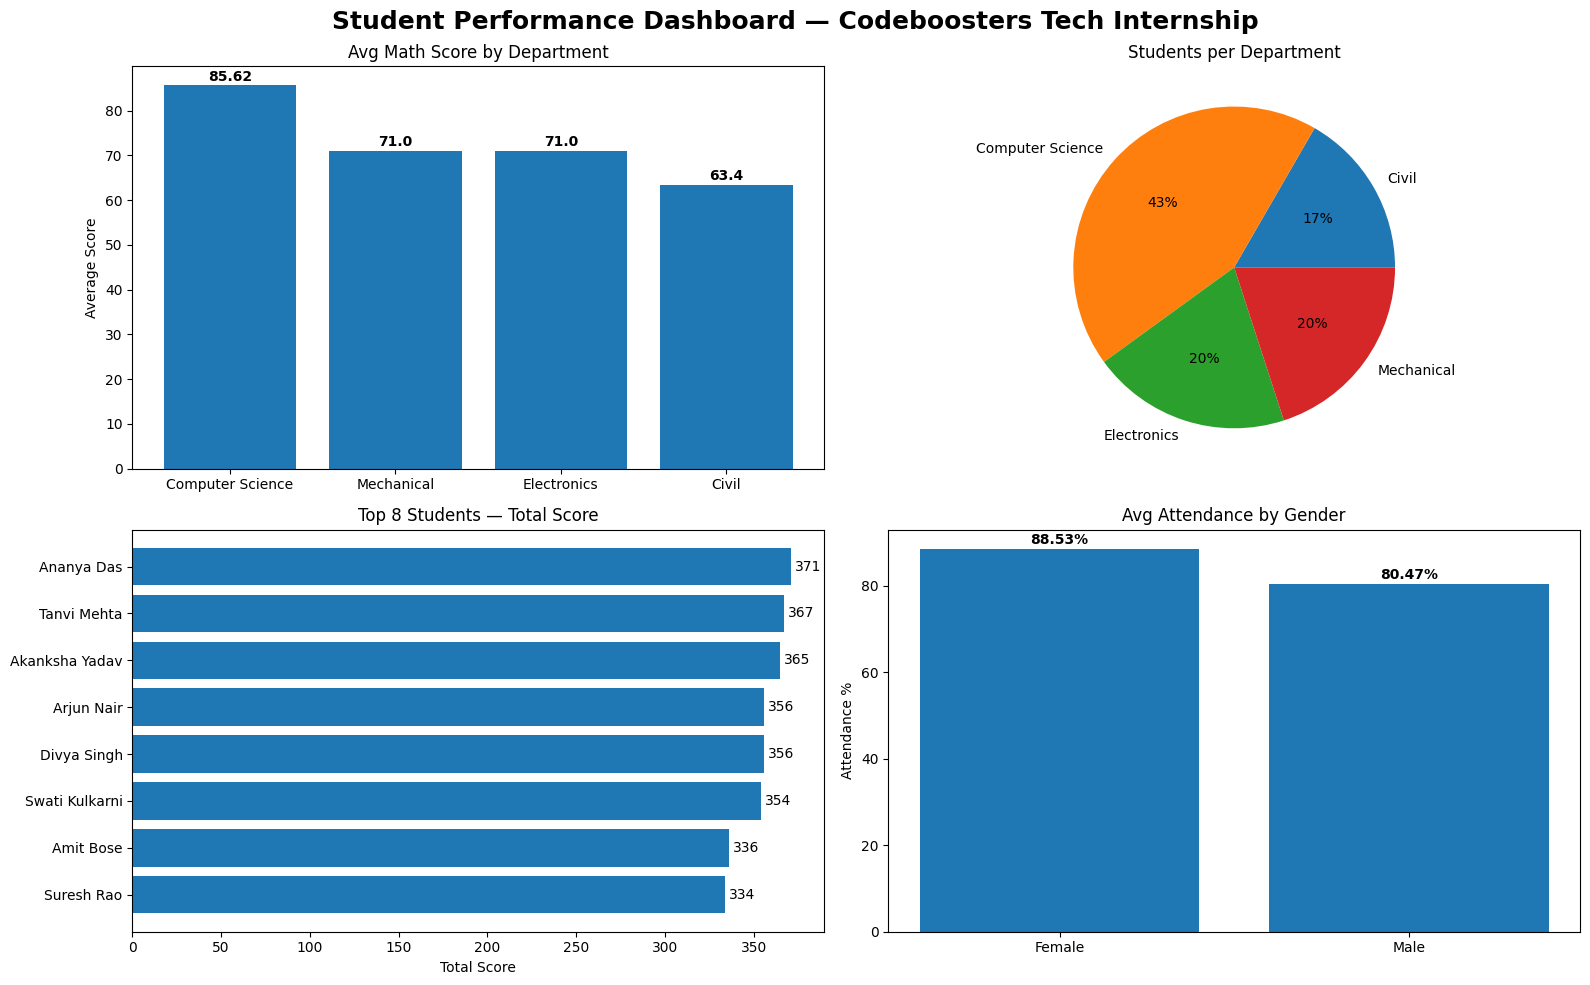

In [32]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    "Student Performance Dashboard — Codeboosters Tech Internship",
    fontsize=18,
    fontweight='bold'
)


axs[0,0].bar(chart1['department'], chart1['avg_math_score'])
axs[0,0].set_title("Avg Math Score by Department")
axs[0,0].set_ylabel("Average Score")

for i, v in enumerate(chart1['avg_math_score']):
    axs[0,0].text(i, v + 1, str(v), ha='center', fontweight='bold')


axs[0,1].pie(chart2['student_count'], labels=chart2['department'], autopct='%1.0f%%')
axs[0,1].set_title("Students per Department")


axs[1,0].barh(chart3['name'], chart3['total_score'])
axs[1,0].invert_yaxis()
axs[1,0].set_title("Top 8 Students — Total Score")
axs[1,0].set_xlabel("Total Score")

for i, v in enumerate(chart3['total_score']):
    axs[1,0].text(v + 2, i, str(v), va='center')


axs[1,1].bar(chart4['gender'], chart4['avg_attendance'])
axs[1,1].set_title("Avg Attendance by Gender")
axs[1,1].set_ylabel("Attendance %")

for i, v in enumerate(chart4['avg_attendance']):
    axs[1,1].text(i, v + 1, f"{v}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [35]:
print("\nQ1. Average programming score for female students:")

q1 = """
SELECT ROUND(AVG(programming_score),2) AS avg_programming_score
FROM students
WHERE gender='Female'
"""
ans1 = pd.read_sql_query(q1, conn)

print(ans1)


Q1. Average programming score for female students:
   avg_programming_score
0                   70.2


In [37]:
print("\nQ2. Difference between WHERE and HAVING")

print("""
WHERE:
- Filters rows BEFORE grouping.

Ex:
SELECT * FROM students
WHERE department='Computer Science';

HAVING:
- Filters grouped data AFTER GROUP BY.

Ex:
SELECT department, AVG(total_score)
FROM students
GROUP BY department
HAVING AVG(total_score) > 300;
""")


Q2. Difference between WHERE and HAVING

WHERE:
- Filters rows BEFORE grouping.

Ex:
SELECT * FROM students
WHERE department='Computer Science';

HAVING:
- Filters grouped data AFTER GROUP BY.

Ex:
SELECT department, AVG(total_score)
FROM students
GROUP BY department
HAVING AVG(total_score) > 300;



In [38]:
print("\nQ3. Departments where average attendance > 85%")

q3 = """
SELECT department,
ROUND(AVG(attendance_percentage),2) AS avg_attendance
FROM students
GROUP BY department
HAVING AVG(attendance_percentage) > 85
"""

ans3 = pd.read_sql_query(q3, conn)

print(ans3)


Q3. Departments where average attendance > 85%
         department  avg_attendance
0  Computer Science           90.69


In [39]:
print("\nQ4. About pd.read_sql_query()")

print("""
pd.read_sql_query():
- Executes SQL query
- Returns the result as a Pandas DataFrame

Required arguments:
1. SQL query
2. Database connection object
""")


Q4. About pd.read_sql_query()

pd.read_sql_query():
- Executes SQL query
- Returns the result as a Pandas DataFrame

Required arguments:
1. SQL query
2. Database connection object



In [40]:
print("\nQ5. Query for Average PROGRAMMING score chart")

q5 = """
SELECT department,
ROUND(AVG(programming_score),2) AS avg_programming_score
FROM students
GROUP BY department
"""

ans5 = pd.read_sql_query(q5, conn)

print(ans5)


Q5. Query for Average PROGRAMMING score chart
         department  avg_programming_score
0             Civil                  40.60
1  Computer Science                  89.23
2       Electronics                  61.50
3        Mechanical                  49.33


In [41]:
conn.close()